In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

houses = pd.read_csv('houses.csv', keep_default_na=False, na_values=['NA',''])
houses.head()

# Aqui, defini que apenas "NA" e '' serão considerados como valores nulos
# "None" não será considerado nulo pois, em todas colunas que aparece, tem significado

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### ``OverallCond``

Hipótese nula: ``OverallCond`` não influencia no preço das casas (``SalePrice``)

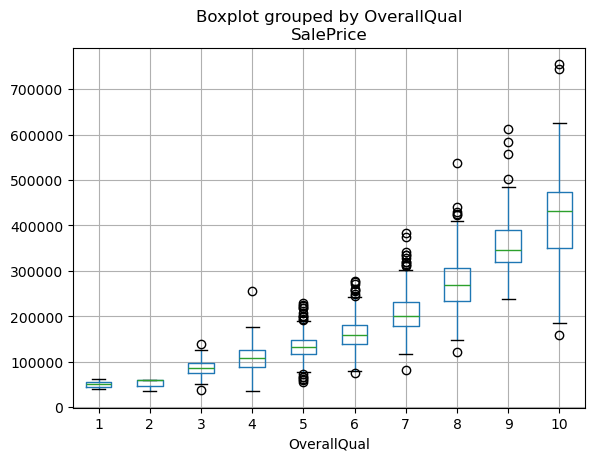

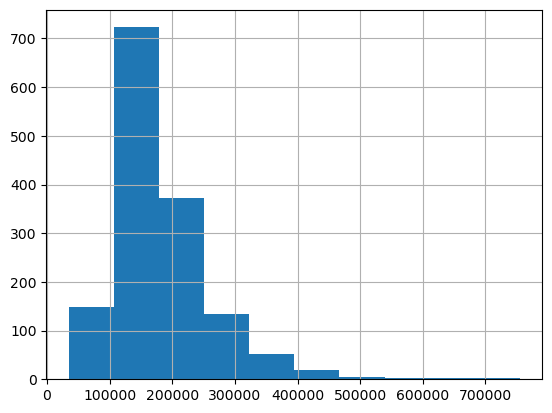

In [2]:
# Boxplot de SalePrice para variável categorica 'OverallQual'

houses.boxplot(column='SalePrice', by='OverallQual')
plt.show()
houses.SalePrice.hist()
plt.show()

In [3]:
# Teste de Shapiro-Wilk para resíduos p/ verficar normalidade
import scipy.stats as st

def qqanalise(dados,distr="norm"):
  plt.figure(figsize=(12,4))
  plt.subplot(1,2,1)
  plt.hist(dados)
  plt.subplot(1,2,2)
  st.probplot(dados, dist=distr,plot=plt)
  plt.show()

# Calc residuos por grupo de OverallQual
residuos = []
for qual in sorted(houses.OverallQual.unique()):
    grupo = houses[houses.OverallQual == qual] 
    residuos.extend(grupo.SalePrice - grupo.SalePrice.mean())